# Metro Station Demand Forecasting

This methodology builds a complete machine learning workflow for **metro station demand forecasting**.

The workflow includes:

- data loading and understanding
- data cleaning
- exploratory data analysis
- feature engineering
- preprocessing
- feature selection
- time-based cross validation
- multiple model training
- transformer model experiments
- model comparison
- final test evaluation
- residual and error analysis

## 1. Import libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

import warnings 
warnings.filterwarnings('ignore')

## 2. Load the dataset

Read the CSV file and take a quick look at the data.


In [ ]:
df = pd.read_csv("Metro Demand Forecasting.csv")
df.head()

,date_time,station_id,station_type,is_interchange,distance_to_cbd_km,capacity_per_hour,hour_of_day,day_of_week,is_weekend,month,is_holiday,school_term_flag,payday_flag,temperature_c,rainfall_mm,visibility_km,event_nearby_flag,event_size,headway_min,delay_min,service_status,lag_1h_demand,lag_24h_demand,demand
0,2024-01-01 00:00:00,S001,residential,0,5.43,3007,0,Monday,0,1,1,1,0,20.48,0.0,9.87,0,0.0,8.5,0.0,normal,111.0,111.0,69
1,2024-01-01 01:00:00,S001,residential,0,5.43,3007,1,Monday,0,1,1,1,0,20.47,0.0,9.75,0,0.0,8.5,0.0,normal,69.0,112.0,77
2,2024-01-01 02:00:00,S001,residential,0,5.43,3007,2,Monday,0,1,1,1,0,NaN,0.0,10.00,0,0.0,8.5,0.0,normal,77.0,111.0,89
3,2024-01-01 03:00:00,S001,residential,0,5.43,3007,3,Monday,0,1,1,1,0,NaN,0.0,9.87,0,0.0,8.5,0.0,normal,89.0,111.0,72
4,2024-01-01 04:00:00,S001,residential,0,5.43,3007,4,Monday,0,1,1,1,0,18.13,0.0,9.27,0,0.0,8.5,0.0,normal,72.0,120.0,79


## 3. Basic structure of the dataset

Check the shape, column names, data types, and missing values.


In [7]:
print("Shape of dataset:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())
print()
print(df.info())

Shape of dataset: (561408, 24)

Columns:
['date_time', 'station_id', 'station_type', 'is_interchange', 'distance_to_cbd_km', 'capacity_per_hour', 'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'is_holiday', 'school_term_flag', 'payday_flag', 'temperature_c', 'rainfall_mm', 'visibility_km', 'event_nearby_flag', 'event_size', 'headway_min', 'delay_min', 'service_status', 'lag_1h_demand', 'lag_24h_demand', 'demand']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561408 entries, 0 to 561407
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   date_time           561408 non-null  object 
 1   station_id          561408 non-null  object 
 2   station_type        561408 non-null  object 
 3   is_interchange      561408 non-null  int64  
 4   distance_to_cbd_km  561408 non-null  float64
 5   capacity_per_hour   561408 non-null  int64  
 6   hour_of_day         561408 non-null  int64  
 7   day_of_wee

In [8]:
missing_df = pd.DataFrame({
    "column": df.columns,
    "missing_values": df.isna().sum().values,
    "missing_percent": (df.isna().sum().values / len(df)) * 100
}).sort_values("missing_values", ascending=False)

missing_df

,column,missing_values,missing_percent
17,event_size,1992,0.354822
15,visibility_km,1920,0.341997
13,temperature_c,512,0.091199
0,date_time,0,0.000000
1,station_id,0,0.000000
22,lag_24h_demand,0,0.000000
21,lag_1h_demand,0,0.000000
20,service_status,0,0.000000
19,delay_min,0,0.000000
18,headway_min,0,0.000000


## 4. Initial cleaning and preparation

In this step:

- convert `date_time` into datetime format
- sort the data properly
- check duplicates
- review the target variable


In [10]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values(["station_id", "date_time"]).reset_index(drop=True)

print("Duplicate rows:", df.duplicated().sum())
print()
print(df["demand"].describe())

Duplicate rows: 0

count    561408.000000
mean        415.532552
std         283.184822
min           5.000000
25%         220.000000
50%         331.000000
75%         542.000000
max        2112.000000
Name: demand, dtype: float64


## 5. Exploratory Data Analysis

This section helps us understand how demand behaves across time, station type, and service conditions.


### 5.1 Distribution of target variable


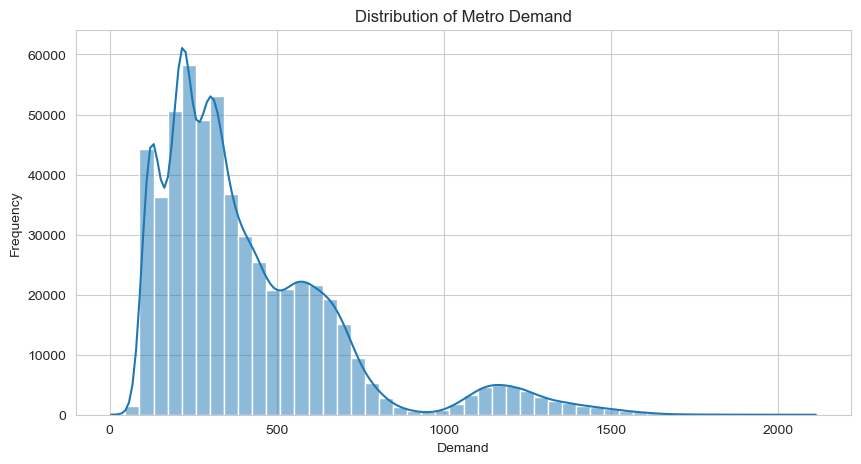

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df["demand"], bins=50, kde=True)
plt.title("Distribution of Metro Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

### 5.2 Average demand by hour of day


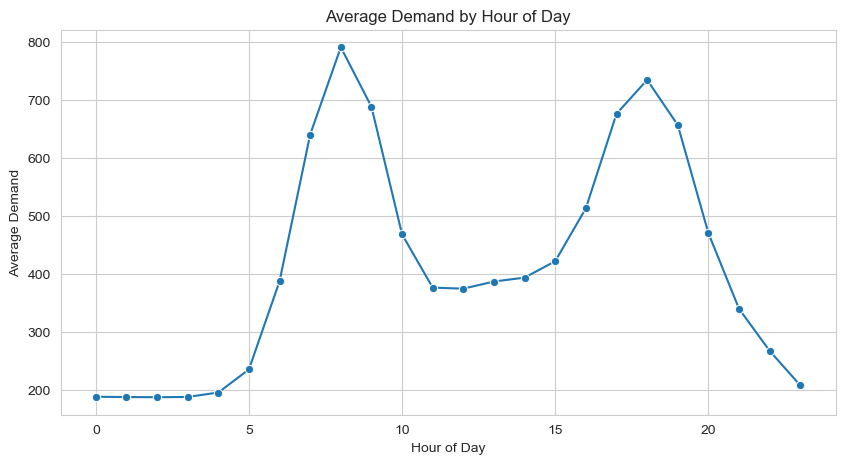

In [15]:
hourly_demand = df.groupby("hour_of_day")["demand"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_demand, x="hour_of_day", y="demand", marker="o")
plt.title("Average Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.show()

### 5.3 Average demand by day of week


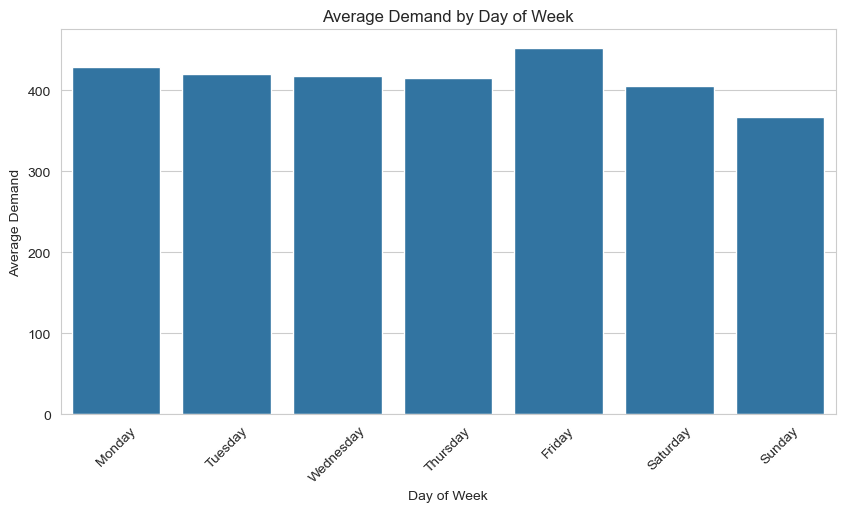

In [17]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_demand = df.groupby("day_of_week")["demand"].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=dow_demand, x="day_of_week", y="demand")
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

### 5.4 Average demand by station type


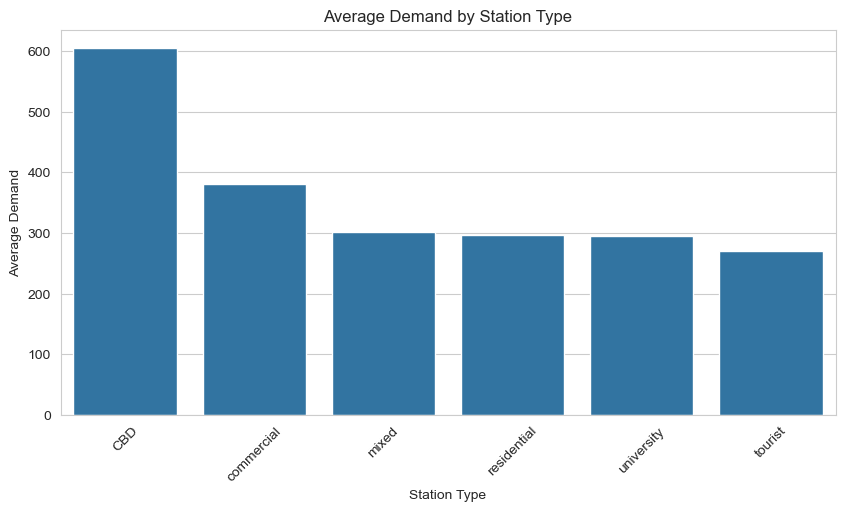

In [19]:
station_type_demand = df.groupby("station_type")["demand"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=station_type_demand, x="station_type", y="demand")
plt.title("Average Demand by Station Type")
plt.xlabel("Station Type")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

### 5.5 Demand trend over time

To make the trend easier to read, aggregate demand to daily totals.


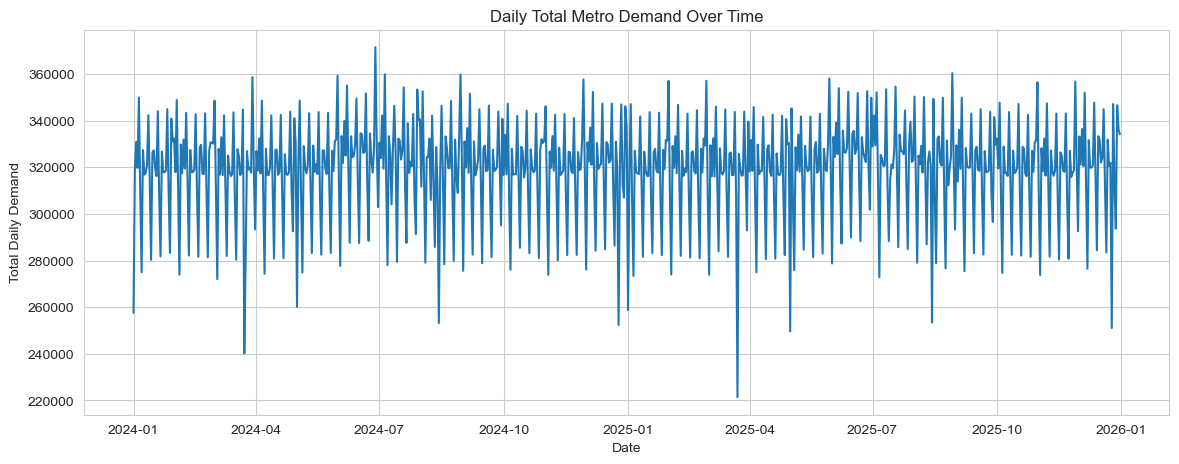

In [21]:
daily_demand = df.groupby(df["date_time"].dt.date)["demand"].sum().reset_index()
daily_demand["date_time"] = pd.to_datetime(daily_demand["date_time"])

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_demand, x="date_time", y="demand")
plt.title("Daily Total Metro Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.show()

### 5.6 Correlation among numeric variables


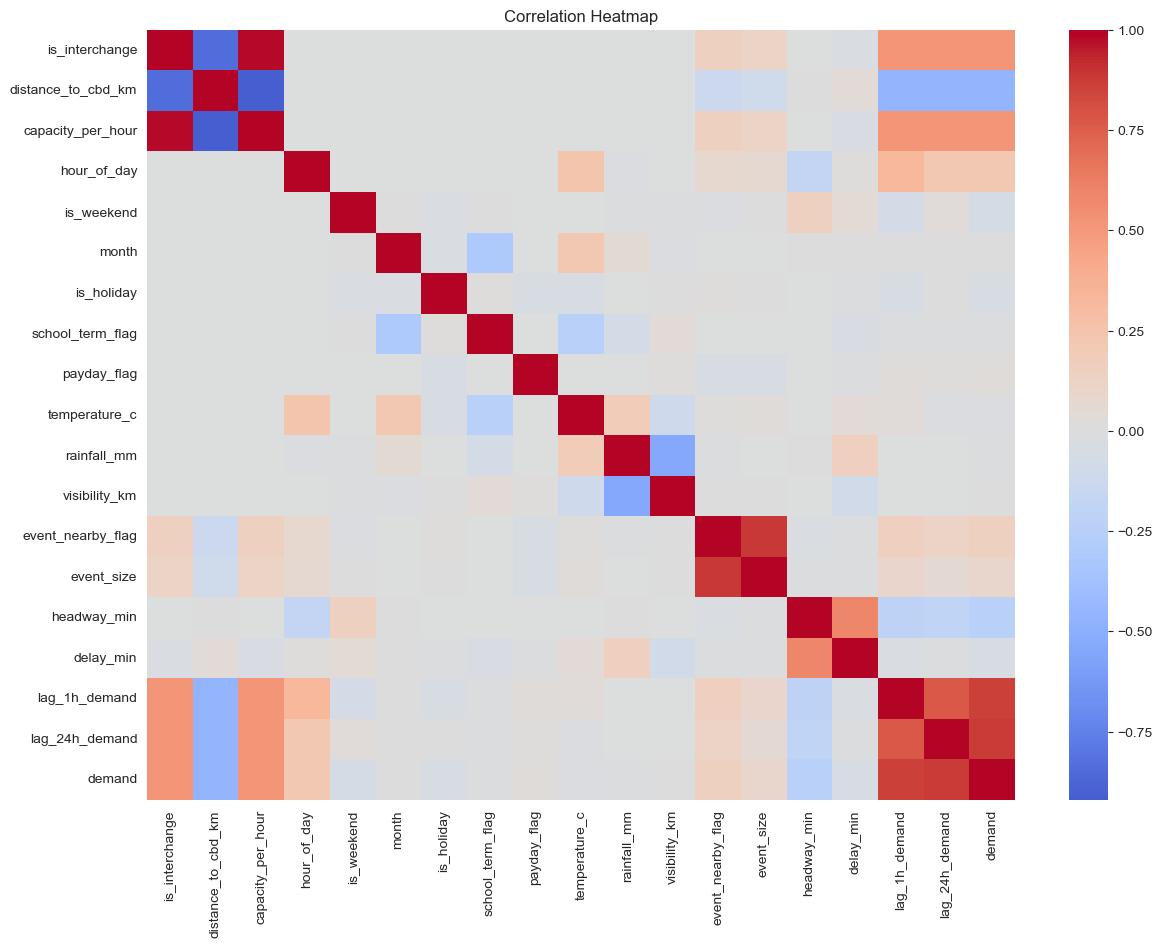

In [23]:
numeric_cols_for_corr = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr_matrix = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 6. Feature engineering

Create a few additional features that may help demand forecasting:

- calendar-based features from `date_time`
- cyclical time features for hour, day, and month
- peak and off-peak indicators
- recent demand summary features
- service disruption and delay ratio features
- rain flag


In [25]:
df["day_of_month"] = df["date_time"].dt.day
df["week_of_year"] = df["date_time"].dt.isocalendar().week.astype(int)
df["month"] = df["date_time"].dt.month
df["quarter"] = df["date_time"].dt.quarter
df["is_weekend"] = df["date_time"].dt.dayofweek.isin([5, 6]).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["week_sin"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
df["week_cos"] = np.cos(2 * np.pi * df["week_of_year"] / 52)

df["is_peak_hour"] = df["hour_of_day"].isin([7, 8, 9, 17, 18, 19]).astype(int)
df["is_off_peak"] = df["hour_of_day"].isin([0, 1, 2, 3, 4, 5, 22, 23]).astype(int)

df["recent_demand_avg"] = (df["lag_1h_demand"] + df["lag_24h_demand"]) / 2
df["recent_demand_gap"] = df["lag_1h_demand"] - df["lag_24h_demand"]
df["recent_demand_ratio"] = df["lag_1h_demand"] / df["lag_24h_demand"].replace(0, np.nan)

df["delay_headway_ratio"] = df["delay_min"] / df["headway_min"].replace(0, np.nan)
df["rain_flag"] = (df["rainfall_mm"] > 0).astype(int)
df["reduced_service_flag"] = (df["service_status"] != "normal").astype(int)

df = df.replace([np.inf, -np.inf], np.nan)

df.head()


,date_time,station_id,station_type,is_interchange,distance_to_cbd_km,capacity_per_hour,hour_of_day,day_of_week,is_weekend,month,is_holiday,school_term_flag,payday_flag,temperature_c,rainfall_mm,visibility_km,event_nearby_flag,event_size,headway_min,delay_min,service_status,lag_1h_demand,lag_24h_demand,demand,day_of_month,week_of_year,quarter,hour_sin,hour_cos,month_sin,month_cos,week_sin,week_cos,is_peak_hour,is_off_peak,recent_demand_avg,recent_demand_gap,recent_demand_ratio,delay_headway_ratio,rain_flag,reduced_service_flag
0,2024-01-01 00:00:00,S001,residential,0,5.43,3007,0,Monday,0,1,1,1,0,20.48,0.0,9.87,0,0.0,8.5,0.0,normal,111.0,111.0,69,1,1,1,0.000000,1.000000,0.5,0.866025,0.120537,0.992709,0,1,111.0,0.0,1.000000,0.0,0,0
1,2024-01-01 01:00:00,S001,residential,0,5.43,3007,1,Monday,0,1,1,1,0,20.47,0.0,9.75,0,0.0,8.5,0.0,normal,69.0,112.0,77,1,1,1,0.258819,0.965926,0.5,0.866025,0.120537,0.992709,0,1,90.5,-43.0,0.616071,0.0,0,0
2,2024-01-01 02:00:00,S001,residential,0,5.43,3007,2,Monday,0,1,1,1,0,NaN,0.0,10.00,0,0.0,8.5,0.0,normal,77.0,111.0,89,1,1,1,0.500000,0.866025,0.5,0.866025,0.120537,0.992709,0,1,94.0,-34.0,0.693694,0.0,0,0
3,2024-01-01 03:00:00,S001,residential,0,5.43,3007,3,Monday,0,1,1,1,0,NaN,0.0,9.87,0,0.0,8.5,0.0,normal,89.0,111.0,72,1,1,1,0.707107,0.707107,0.5,0.866025,0.120537,0.992709,0,1,100.0,-22.0,0.801802,0.0,0,0
4,2024-01-01 04:00:00,S001,residential,0,5.43,3007,4,Monday,0,1,1,1,0,18.13,0.0,9.27,0,0.0,8.5,0.0,normal,72.0,120.0,79,1,1,1,0.866025,0.500000,0.5,0.866025,0.120537,0.992709,0,1,96.0,-48.0,0.600000,0.0,0,0


## 7. Define features and target

We will predict `demand`.


In [27]:
target = "demand"

drop_cols = ["demand", "date_time"]

X = df.drop(columns=drop_cols).copy()
y = df[target].copy()

print("Number of features before encoding:", X.shape[1])

Number of features before encoding: 39


## 8. Train, validation, and test split

Because this is a forecasting problem, we should split the data **by time** instead of random shuffling.

- Train: up to June 2025
- Validation: July 2025 to September 2025
- Test: October 2025 to December 2025


In [29]:
train_df = df[df["date_time"] <= "2025-06-30 23:00:00"].copy()
valid_df = df[(df["date_time"] > "2025-06-30 23:00:00") & (df["date_time"] <= "2025-09-30 23:00:00")].copy()
test_df = df[df["date_time"] > "2025-09-30 23:00:00"].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (420096, 41)
Validation shape: (70656, 41)
Test shape: (70656, 41)


In [30]:
X_train = train_df.drop(columns=["demand", "date_time"]).copy()
y_train = train_df["demand"].copy()

X_valid = valid_df.drop(columns=["demand", "date_time"]).copy()
y_valid = valid_df["demand"].copy()

X_test = test_df.drop(columns=["demand", "date_time"]).copy()
y_test = test_df["demand"].copy()

## 9. Preprocessing

This step includes:

- separating numeric and categorical columns
- filling missing values using training data only
- one-hot encoding categorical variables


In [32]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print()
print("Numeric columns:", numeric_cols)

Categorical columns: ['station_id', 'station_type', 'day_of_week', 'service_status']

Numeric columns: ['is_interchange', 'distance_to_cbd_km', 'capacity_per_hour', 'hour_of_day', 'is_weekend', 'month', 'is_holiday', 'school_term_flag', 'payday_flag', 'temperature_c', 'rainfall_mm', 'visibility_km', 'event_nearby_flag', 'event_size', 'headway_min', 'delay_min', 'lag_1h_demand', 'lag_24h_demand', 'day_of_month', 'week_of_year', 'quarter', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'is_peak_hour', 'is_off_peak', 'recent_demand_avg', 'recent_demand_gap', 'recent_demand_ratio', 'delay_headway_ratio', 'rain_flag', 'reduced_service_flag']


In [33]:
train_medians = X_train[numeric_cols].median()
train_modes = X_train[categorical_cols].mode().iloc[0]

for col in numeric_cols:
    X_train[col] = X_train[col].fillna(train_medians[col])
    X_valid[col] = X_valid[col].fillna(train_medians[col])
    X_test[col] = X_test[col].fillna(train_medians[col])

for col in categorical_cols:
    X_train[col] = X_train[col].fillna(train_modes[col])
    X_valid[col] = X_valid[col].fillna(train_modes[col])
    X_test[col] = X_test[col].fillna(train_modes[col])

In [34]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_valid = pd.get_dummies(X_valid, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoded train shape:", X_train.shape)
print("Encoded validation shape:", X_valid.shape)
print("Encoded test shape:", X_test.shape)

Encoded train shape: (420096, 79)
Encoded validation shape: (70656, 79)
Encoded test shape: (70656, 79)


## 10. Feature selection

Use an **Extra Trees Regressor** to estimate feature importance and keep the most useful predictors.

This is a simple and effective model-based feature selection method for regression problems.


In [36]:
feature_sample_size = min(120000, len(X_train))
feature_sample_index = X_train.sample(feature_sample_size, random_state=42).index

X_feature_sample = X_train.loc[feature_sample_index]
y_feature_sample = y_train.loc[feature_sample_index]

feature_selector = ExtraTreesRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

feature_selector.fit(X_feature_sample, y_feature_sample)

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": feature_selector.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
29,recent_demand_avg,0.318675
17,lag_24h_demand,0.208271
16,lag_1h_demand,0.106562
27,is_peak_hour,0.082336
0,is_interchange,0.056962
14,headway_min,0.048795
4,is_weekend,0.041642
28,is_off_peak,0.037515
2,capacity_per_hour,0.027749
22,hour_cos,0.009096


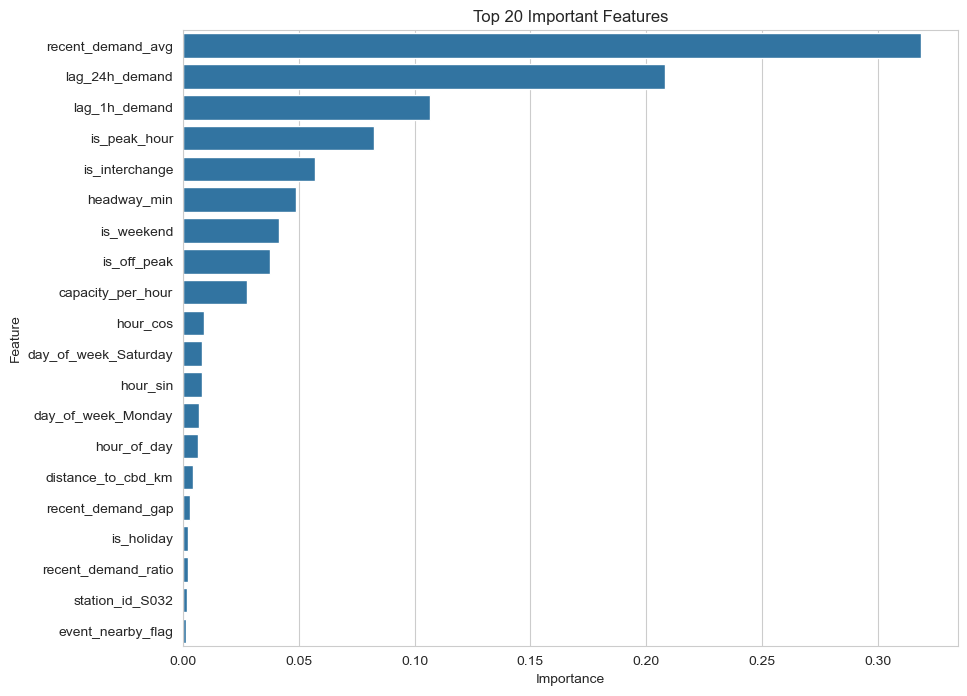

In [37]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [38]:
selected_features = feature_importance_df.head(25)["feature"].tolist()

X_train_selected = X_train[selected_features].copy()
X_valid_selected = X_valid[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("Selected features:")
print(selected_features)
print()
print("Number of selected features:", len(selected_features))

Selected features:
['recent_demand_avg', 'lag_24h_demand', 'lag_1h_demand', 'is_peak_hour', 'is_interchange', 'headway_min', 'is_weekend', 'is_off_peak', 'capacity_per_hour', 'hour_cos', 'day_of_week_Saturday', 'hour_sin', 'day_of_week_Monday', 'hour_of_day', 'distance_to_cbd_km', 'recent_demand_gap', 'is_holiday', 'recent_demand_ratio', 'station_id_S032', 'event_nearby_flag', 'station_type_tourist', 'station_type_mixed', 'day_of_week_Sunday', 'visibility_km', 'day_of_month']

Number of selected features: 25


## 11. Build multiple regression models

I will compare several models:

- Linear Regression
- Ridge Regression
- Decision Tree Regressor
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor
- HistGradientBoosting Regressor

For the tree-based models, a training sample is used to keep runtime practical.


In [40]:
tree_train_size = min(200000, len(X_train_selected))
tree_train_index = X_train_selected.sample(tree_train_size, random_state=42).index

X_train_tree = X_train_selected.loc[tree_train_index]
y_train_tree = y_train.loc[tree_train_index]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=150,
        max_depth=5,
        random_state=42
    ),
    "HistGradient Boosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_depth=12,
        random_state=42
    )
}

tree_based_model_names = [
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Gradient Boosting",
    "HistGradient Boosting"
]


## 12. Time-series cross validation

This section adds **cross validation** using `TimeSeriesSplit`.

For forecasting work, normal random cross validation is not suitable because it can leak future information into the training data. Time-series cross validation keeps the order of time and checks whether the model works across different time periods.


In [42]:
def calculate_metrics(y_true, y_pred):
    """Return MAE, RMSE, R2, and safe MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    denominator = np.where(np.asarray(y_true) == 0, np.nan, np.asarray(y_true))
    mape = np.nanmean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / denominator)) * 100

    return mae, rmse, r2, mape


cv_sample_size = min(120000, len(X_train_selected))
cv_data = (
    pd.concat([X_train_selected, y_train.rename("demand")], axis=1)
    .sort_index()
    .tail(cv_sample_size)
)

X_cv = cv_data[selected_features]
y_cv = cv_data["demand"]

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for name, model in models.items():
    fold_scores = []

    for fold, (train_index, valid_index) in enumerate(tscv.split(X_cv), start=1):
        X_fold_train = X_cv.iloc[train_index]
        y_fold_train = y_cv.iloc[train_index]
        X_fold_valid = X_cv.iloc[valid_index]
        y_fold_valid = y_cv.iloc[valid_index]

        fold_model = clone(model)

        if name in tree_based_model_names:
            fold_train_size = min(60000, len(X_fold_train))
            fold_train_index = X_fold_train.sample(fold_train_size, random_state=42).index
            fold_model.fit(X_fold_train.loc[fold_train_index], y_fold_train.loc[fold_train_index])
        else:
            fold_model.fit(X_fold_train, y_fold_train)

        fold_pred = fold_model.predict(X_fold_valid)
        mae, rmse, r2, mape = calculate_metrics(y_fold_valid, fold_pred)
        fold_scores.append([mae, rmse, r2, mape])

    fold_scores = np.array(fold_scores)
    cv_results.append([
        name,
        fold_scores[:, 0].mean(),
        fold_scores[:, 1].mean(),
        fold_scores[:, 2].mean(),
        fold_scores[:, 3].mean()
    ])

cv_results_df = pd.DataFrame(
    cv_results,
    columns=["Model", "CV_MAE", "CV_RMSE", "CV_R2", "CV_MAPE"]
).sort_values("CV_RMSE").reset_index(drop=True)

cv_results_df


,Model,CV_MAE,CV_RMSE,CV_R2,CV_MAPE
0,Gradient Boosting,4.449578e+01,7.366699e+01,8.065178e-01,1.084102e+01
1,HistGradient Boosting,4.372366e+01,7.437578e+01,7.862805e-01,1.071665e+01
2,Random Forest,4.517849e+01,7.675539e+01,7.707450e-01,1.117674e+01
3,Extra Trees,4.602937e+01,7.700990e+01,7.533630e-01,1.168069e+01
4,Decision Tree,4.928997e+01,8.385272e+01,7.119542e-01,1.231462e+01
5,Ridge Regression,7.176150e+01,9.742297e+01,7.871867e-01,1.983099e+01
6,Linear Regression,6.518188e+06,8.451647e+06,-1.599223e+10,2.894884e+06


## 13. Train the models and evaluate on the validation set

We will compare the models using:

- MAE
- RMSE
- R²
- MAPE


In [44]:
results = []
validation_predictions = {}

for name, model in models.items():
    if name in tree_based_model_names:
        model.fit(X_train_tree, y_train_tree)
    else:
        model.fit(X_train_selected, y_train)

    valid_pred = model.predict(X_valid_selected)
    validation_predictions[name] = valid_pred

    mae, rmse, r2, mape = calculate_metrics(y_valid, valid_pred)

    results.append([name, mae, rmse, r2, mape])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "MAPE"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df


,Model,MAE,RMSE,R2,MAPE
0,Extra Trees,25.892671,41.068625,0.979422,6.948265
1,HistGradient Boosting,27.452010,42.227749,0.978244,7.273435
2,Random Forest,26.850480,42.876903,0.977570,7.272266
3,Gradient Boosting,30.024715,45.173725,0.975102,8.119272
4,Decision Tree,29.585687,46.985201,0.973066,8.104192
5,Linear Regression,72.422703,105.966355,0.863000,21.035254
6,Ridge Regression,72.426042,105.966516,0.862999,21.036319


## 14. Transformer model experiments

This section adds optional transformer model experiments.

The transformer model is useful because attention layers can learn relationships between many demand features at the same time. The code below tries two transformer models:

- Small Tabular Transformer
- Deeper Tabular Transformer


In [46]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    torch_available = True
except ImportError:
    torch_available = False
    print("PyTorch is not installed, so the transformer model section is skipped.")


if torch_available:
    class TabularTransformerRegressor(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.10):
            super().__init__()
            self.feature_embedding = nn.Linear(1, d_model)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout,
                batch_first=True
            )
            self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.regressor = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, 1)
            )

        def forward(self, x):
            x = x.unsqueeze(-1)
            x = self.feature_embedding(x)
            x = self.transformer_encoder(x)
            x = x.mean(dim=1)
            return self.regressor(x).squeeze(-1)


    def train_transformer_model(config, X_train_data, y_train_data, X_valid_data, y_valid_data):
        transformer_train_size = min(50000, len(X_train_data))
        transformer_index = X_train_data.sample(transformer_train_size, random_state=42).index

        X_tr = X_train_data.loc[transformer_index].copy()
        y_tr = y_train_data.loc[transformer_index].copy()

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_valid_data)

        y_mean = y_tr.mean()
        y_std = y_tr.std()
        y_tr_scaled = (y_tr - y_mean) / y_std

        train_dataset = TensorDataset(
            torch.tensor(X_tr_scaled, dtype=torch.float32),
            torch.tensor(y_tr_scaled.values, dtype=torch.float32)
        )
        train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

        model = TabularTransformerRegressor(
            n_features=X_tr.shape[1],
            d_model=config["d_model"],
            nhead=config["nhead"],
            num_layers=config["num_layers"],
            dropout=config["dropout"]
        )

        optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)
        loss_function = nn.MSELoss()

        model.train()
        for epoch in range(config["epochs"]):
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                batch_pred = model(batch_x)
                loss = loss_function(batch_pred, batch_y)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            valid_pred_scaled = model(torch.tensor(X_val_scaled, dtype=torch.float32)).numpy()

        valid_pred = (valid_pred_scaled * y_std) + y_mean

        return model, scaler, y_mean, y_std, valid_pred


    transformer_configs = {
        "Small Tabular Transformer": {
            "d_model": 32,
            "nhead": 4,
            "num_layers": 2,
            "dropout": 0.10,
            "learning_rate": 0.001,
            "epochs": 3
        },
        "Deeper Tabular Transformer": {
            "d_model": 64,
            "nhead": 4,
            "num_layers": 3,
            "dropout": 0.15,
            "learning_rate": 0.0007,
            "epochs": 3
        }
    }

    transformer_results = []
    transformer_predictions = {}
    fitted_transformers = {}

    for name, config in transformer_configs.items():
        transformer_model, transformer_scaler, transformer_y_mean, transformer_y_std, transformer_valid_pred = train_transformer_model(
            config,
            X_train_selected,
            y_train,
            X_valid_selected,
            y_valid
        )

        transformer_predictions[name] = transformer_valid_pred
        fitted_transformers[name] = {
            "model": transformer_model,
            "scaler": transformer_scaler,
            "y_mean": transformer_y_mean,
            "y_std": transformer_y_std,
            "config": config
        }

        mae, rmse, r2, mape = calculate_metrics(y_valid, transformer_valid_pred)
        transformer_results.append([name, mae, rmse, r2, mape])

    transformer_results_df = pd.DataFrame(
        transformer_results,
        columns=["Model", "MAE", "RMSE", "R2", "MAPE"]
    )

    results_df = pd.concat([results_df, transformer_results_df], axis=0)
    results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df


,Model,MAE,RMSE,R2,MAPE
0,Extra Trees,25.892671,41.068625,0.979422,6.948265
1,HistGradient Boosting,27.452010,42.227749,0.978244,7.273435
2,Random Forest,26.850480,42.876903,0.977570,7.272266
3,Gradient Boosting,30.024715,45.173725,0.975102,8.119272
4,Decision Tree,29.585687,46.985201,0.973066,8.104192
5,Linear Regression,72.422703,105.966355,0.863000,21.035254
6,Ridge Regression,72.426042,105.966516,0.862999,21.036319
7,Deeper Tabular Transformer,142.242170,187.764450,0.569858,49.054935
8,Small Tabular Transformer,147.826284,197.640454,0.523419,48.093316


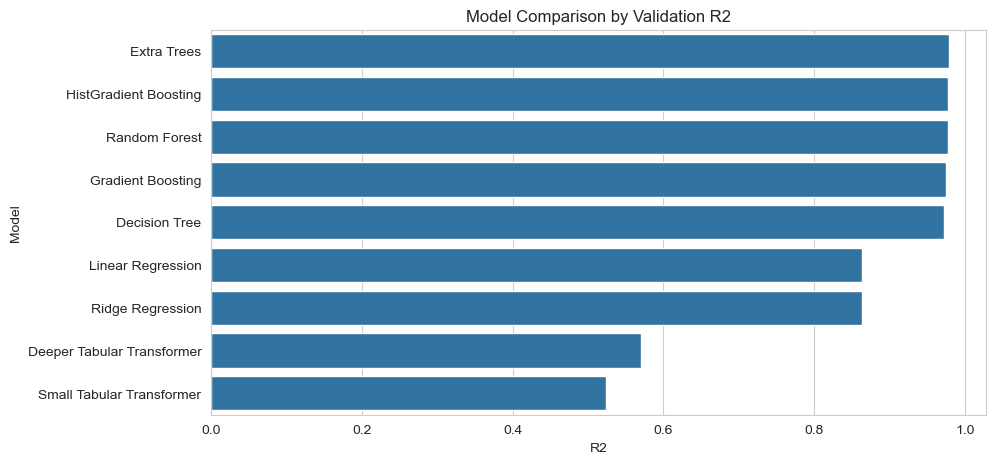

In [47]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="R2", y="Model")
plt.title("Model Comparison by Validation R2")
plt.xlabel("R2")
plt.ylabel("Model")
plt.show()

## 15. Select the best model

The best model is chosen using the lowest validation RMSE.


In [49]:
best_model_name = results_df.loc[0, "Model"]

if best_model_name not in models:
    best_sklearn_model_name = results_df[results_df["Model"].isin(models.keys())].iloc[0]["Model"]
    print("Best overall model based on validation RMSE:", best_model_name)
    print("Best non-transformer model selected for final retraining:", best_sklearn_model_name)
    best_model_name = best_sklearn_model_name
else:
    print("Best model based on validation RMSE:", best_model_name)


Best model based on validation RMSE: Extra Trees


## 16. Retrain the best model on train + validation data

After selecting the best model, combine the training and validation sets and train the final model.


In [51]:
X_train_valid_selected = pd.concat([X_train_selected, X_valid_selected], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

X_train_valid_tree = X_train_valid_selected.copy()
y_train_valid_tree = y_train_valid.copy()

if len(X_train_valid_selected) > 250000:
    final_tree_index = X_train_valid_selected.sample(250000, random_state=42).index
    X_train_valid_tree = X_train_valid_selected.loc[final_tree_index]
    y_train_valid_tree = y_train_valid.loc[final_tree_index]

best_model = clone(models[best_model_name])

if best_model_name in tree_based_model_names:
    best_model.fit(X_train_valid_tree, y_train_valid_tree)
else:
    best_model.fit(X_train_valid_selected, y_train_valid)


## 17. Final evaluation on the test set


In [53]:
test_pred = best_model.predict(X_test_selected)

test_mae, test_rmse, test_r2, test_mape = calculate_metrics(y_test, test_pred)

test_results_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "MAPE"],
    "Value": [test_mae, test_rmse, test_r2, test_mape]
})

test_results_df


,Metric,Value
0,MAE,22.242764
1,RMSE,32.589787
2,R2,0.986718
3,MAPE,5.859394


## 18. Actual vs predicted values

This gives a visual check of how well the final model follows the actual demand values.


In [55]:
comparison_df = pd.DataFrame({
    "date_time": test_df["date_time"].values,
    "actual_demand": y_test.values,
    "predicted_demand": test_pred
})

comparison_df.head()

,date_time,actual_demand,predicted_demand
0,2025-10-01 00:00:00,98,106.461636
1,2025-10-01 01:00:00,96,105.597827
2,2025-10-01 02:00:00,94,105.450493
3,2025-10-01 03:00:00,94,105.725071
4,2025-10-01 04:00:00,131,112.330496


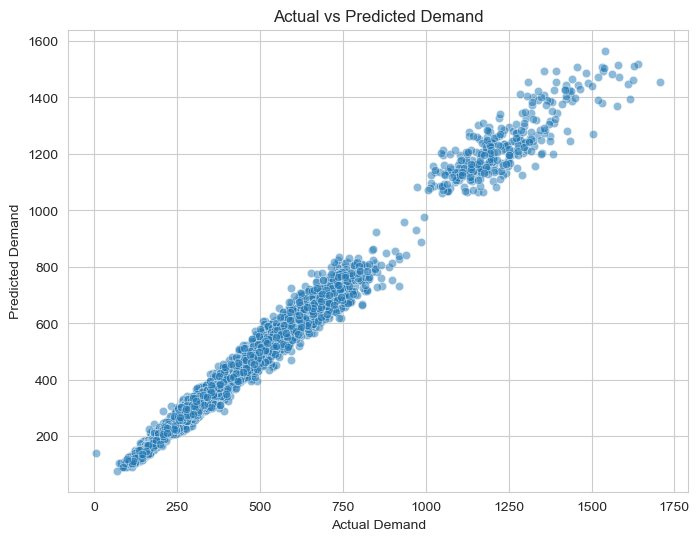

In [56]:
plot_sample = comparison_df.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_sample, x="actual_demand", y="predicted_demand", alpha=0.5)
plt.title("Actual vs Predicted Demand")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.show()

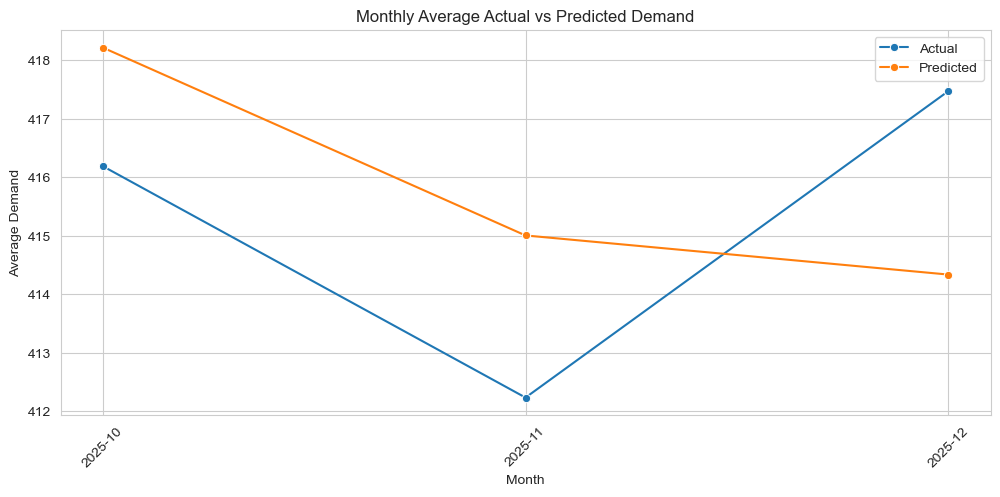

In [57]:
monthly_comparison = comparison_df.copy()
monthly_comparison["month"] = monthly_comparison["date_time"].dt.to_period("M").astype(str)

monthly_summary = monthly_comparison.groupby("month")[["actual_demand", "predicted_demand"]].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_summary, x="month", y="actual_demand", marker="o", label="Actual")
sns.lineplot(data=monthly_summary, x="month", y="predicted_demand", marker="o", label="Predicted")
plt.title("Monthly Average Actual vs Predicted Demand")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

## 19. Residual and error analysis

This section checks where the final model makes larger errors.

This is useful because a model may perform well overall but still struggle during peak hours, rain, disruption, or specific stations.


In [59]:
comparison_df["error"] = comparison_df["actual_demand"] - comparison_df["predicted_demand"]
comparison_df["absolute_error"] = comparison_df["error"].abs()

comparison_df[["actual_demand", "predicted_demand", "error", "absolute_error"]].describe()


,actual_demand,predicted_demand,error,absolute_error
count,70656.000000,70656.000000,70656.000000,70656.000000
mean,415.332824,415.863960,-0.531136,22.242764
std,282.784265,280.983621,32.585689,23.819356
min,5.000000,77.565241,-272.410881,0.000251
25%,220.000000,221.568151,-16.028143,6.780735
50%,331.000000,331.169834,-0.832934,15.213918
75%,542.000000,546.973636,14.447764,29.156757
max,2049.000000,1788.212152,365.109406,365.109406


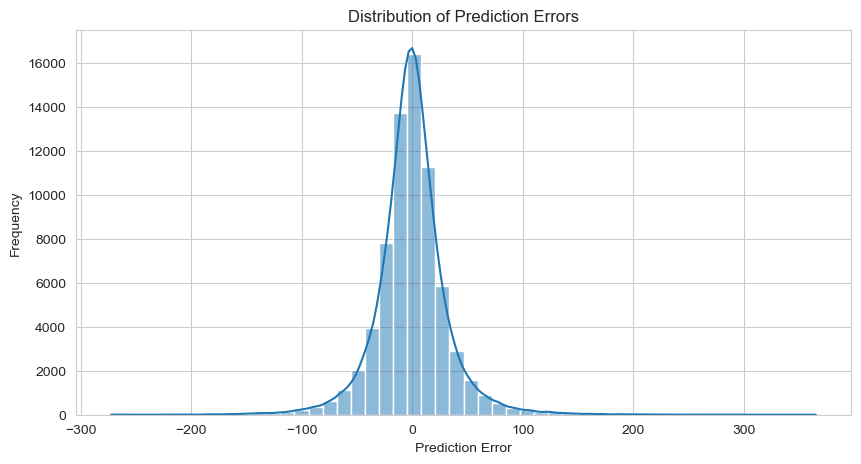

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(comparison_df["error"], bins=50, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()


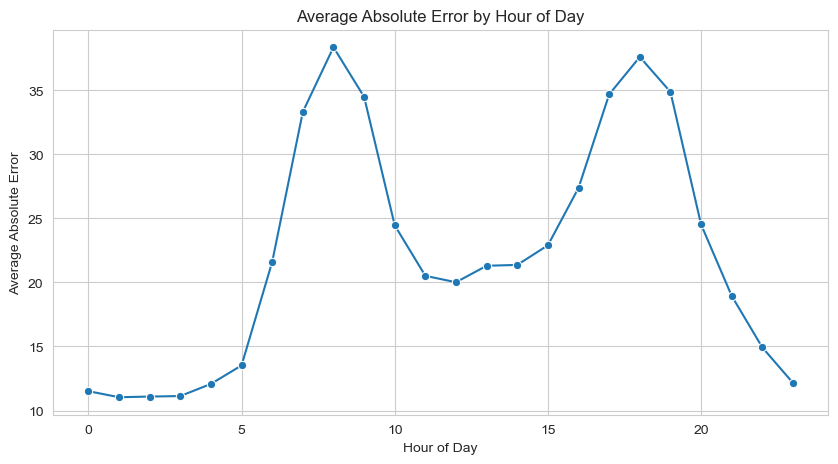

In [61]:
error_by_hour = comparison_df.copy()
error_by_hour["hour_of_day"] = error_by_hour["date_time"].dt.hour

hourly_error_summary = error_by_hour.groupby("hour_of_day")["absolute_error"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_error_summary, x="hour_of_day", y="absolute_error", marker="o")
plt.title("Average Absolute Error by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Absolute Error")
plt.show()


## 20. Final notes

After running this notebook, the key interpretation should come from:

- the cross validation results table
- the validation model comparison table
- the optional transformer model results
- the final test metrics
- the actual vs predicted plots
- the residual and error analysis
- the top feature importance table

These outputs will tell you:

- which model performs best
- whether the model generalizes well to unseen time periods
- whether transformer models improve the forecasting result
- where the final model makes the largest errors
- which operational, temporal, weather, and lag-based features are most useful for forecasting metro demand
